# Linear NN Simulation

We provide a short tutorial to help you understand how to analyze the gradient alignment between local-SSL and global BP-SSL in linear network. In particular, we use figure 2 as an example.

For all theory simulations, refer to README.md and code in ``theory/`` folder.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
os.chdir('../theory')
from linear_nn import ClappMLP
from tqdm import tqdm

# Part 1: Build dataset and Model
We use simple MNIST dataset and MLP model. We start with loading the dataset. For this simulation, we just select 1024 samples from both the train and test dataset.

In [2]:
import torchvision
from torchvision import transforms

DATA_ROOT = '~/Desktop/EPFL/LCN/MNIST/dataset' # Change this to your actual path where the MNIST dataset is stored

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = torchvision.datasets.MNIST(root=DATA_ROOT, download=True, transform=mnist_transform)
test_ds = torchvision.datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=mnist_transform)

train_ds = torch.utils.data.Subset(train_ds, range(1024))
test_ds = torch.utils.data.Subset(test_ds, range(1024))
trainloader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=False)
testloader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

Now we build our MLP model. For simplicity, we just load the parameters from ``theory/configuration_linear.yaml``.

The model we create has split the input image into 2x2 patches, and uses pairs of patches as augmented copies. Patches from the same vertical column of the same image are positive pairs. 

For the loss, we use ClappFlexLoss, which has the flexibility to customize source of context $c^l$ and function $f$ explained in the paper. It also has the function ``forward_analytical_b`` to optimize $B^l$ for fixed input and feedforward weight.

In [3]:
import yaml
with open('./configuration_linear.yaml', "r") as stream:
    model_params = yaml.safe_load(stream)
model_params['device'] = torch.device('cpu') # We just use CPU for this task: (1) computation is simple, (2) we use second-order optimization which is not well supported on GPU

In [4]:
from encoders import MLP, custom_init
from loss import ClappFlexLoss

class SSLMLP(nn.Module):
    def __init__(self, hparams):
        super().__init__()
        self.patch_input = hparams['patch_input']
        if self.patch_input:
            hparams['input_dim'] = hparams['patch_size'] ** 2
            self.patch_size = hparams['patch_size']
        self.encoder = MLP(hparams, act_fun=nn.Identity if hparams['linear_nn'] else nn.ReLU, use_bias=False)
        self.block_grad = hparams['layerwise']
        self.layer_dim = hparams['layer_dim'] if self.block_grad else [hparams['layer_dim'][-1]]
        self.device = hparams['device']
        self.loss = ClappFlexLoss(hparams)
        self.flatten = nn.Flatten()
        self.random_label = None
        self.preact_index = 0
        self.fb_idx = hparams['fb_idx']
        self.custom_init = hparams['custom_init']
        if self.custom_init is not None:
            self.init_mlp()

    def init_mlp(self):
        if self.custom_init == 'default':
            return
        else:
            print('{} weight initialized'.format(self.custom_init))
            for l_seq in self.encoder.blocks:
                custom_init(l_seq[0], self.custom_init)
            return

    def forward(self, x, return_h=False):
        h = self.encode(x, train=True)
        if not self.block_grad:
            h = [h[-1]]
        loss = self.loss(h)
        if return_h:
            return loss, h
        else:
            return loss
        
    def forward_analytical_b(self, x, return_h=False):
        h = self.encode(x, train=True)
        if not self.block_grad:
            h = [h[-1]]
        loss, optim_loss = self.loss.forward_analytical_b(h)
        if return_h:
            return loss, optim_loss, h
        else:
            return loss, optim_loss
    
    def encode(self, x, train=False):
        if self.patch_input:
            x = ( # b, c, y, x
                x.unfold(2, self.patch_size, self.patch_size) # b, c, n_patches_y, x, patch_size
                .unfold(3, self.patch_size, self.patch_size) # b, c, n_patches_y, n_patches_x, patch_size, patch_size
                .permute(2, 3, 0, 1, 4, 5) # n_patches_y, n_patches_x, b, c, patch_size, patch_size
            )
            patched_shape = x.shape
            x = x.flatten(end_dim=2)
        x = self.flatten(x)
        h = self.encoder(x)
        if self.patch_input and not train:
            h = [h_.reshape(patched_shape[0], patched_shape[1], patched_shape[2], -1).mean(dim=(0,1)) for h_ in h]
        return h

    def unfreeze_encoder(self):
        # this function unfreezes the encoder for BP-SSL gradient computation
        for module in self.encoder.blocks:
            for param in module.parameters():
                param.requires_grad = True
            module.train()

    def freeze_encoder(self):
        for module in self.encoder.blocks:
            for param in module.parameters():
                param.requires_grad = False
    
    def compute_proj_align(self):
        # this function checks the alignment between B^l and (W^L ... W^{l+1})^T B^L (W^L ... W^{l+1}).
        # this could be used to confirm the statement in the proof of theorem 3.1
        B_L = self.loss.Wproj[-1].weight.T
        cos_sim = {}
        for l, W_l in enumerate(self.loss.Wproj):
            W_l = self.loss.get_eff_weights(l).T
            key = 'layer_{}'.format(l)
            W_ref = torch.eye(W_l.shape[0])
            for j in range(l+1, len(self.encoder.blocks)):
                W_ref = W_ref @ self.encoder.blocks[j][self.preact_index].weight.T
            W_ref = W_ref @ B_L
            for j in range(len(self.encoder.blocks)-1, self.fb_idx[l], -1):
                W_ref = W_ref @ self.encoder.blocks[j][self.preact_index].weight

            sim_score = torch.dot(W_l.flatten(), W_ref.flatten())/(torch.norm(W_l.flatten()+1e-10) * torch.norm(W_ref.flatten()+1e-10))
            cos_sim[key] = sim_score.item()
        return cos_sim
    
    def compute_lw_error_grad(self, x, y, noise_layer=None):
        # this function computes local-SSL gradient
        assert self.block_grad
        assert self.encoder.block_grad
        self.unfreeze_encoder()
        h = self.encode(x, train=True)
        for h_ in h:
            if h_.is_leaf:
                h_.requires_grad = True 
        if self.random_label is None:
            label_len = int(len(h[-1])) if self.loss.detach_c else int(len(h[-1])/2)
            self.random_label = torch.rand(label_len, device=self.device) < self.loss.transition_prob
        loss = self.loss(h, fixed_label = self.random_label, check_pos_only=False)
        
        all_errors = {}
        all_weight_grads = {}
        all_bias_grads = {}
        for l, (block, x) in enumerate(zip(self.encoder.blocks, h)):
            key = 'layer_{}'.format(l)
            loss[l].backward(retain_graph = True)
            all_errors[key] = torch.autograd.grad(loss[l], x, retain_graph=True)[0]
            all_weight_grads[key] = block[self.preact_index].weight.grad
            #all_bias_grads[key] = block[self.preact_index].bias.grad

        self.freeze_encoder()
        return all_errors, all_weight_grads, all_bias_grads
    

    def compute_ete_error_grad(self, x, y, noise_layer=None):
        # this function computes BP-SSL gradient
        self.encoder.block_grad = False
        x.requires_grad = True
        self.unfreeze_encoder()
        h = self.encode(x, train=True)
        z = h if self.block_grad else [h[-1]]
        if self.random_label is None:
            raise ValueError('need proper random label for comparison')
        loss = self.loss(z, fixed_label = self.random_label, check_pos_only=False)[-1]
        loss.backward(retain_graph = True)
        all_errors = {}
        all_weight_grads = {}
        all_bias_grads = {}
        for l, (block, x) in enumerate(zip(self.encoder.blocks, h)):
            key = 'layer_{}'.format(l)
            all_errors[key] = torch.autograd.grad(loss, x, retain_graph=True)[0]
            all_weight_grads[key] = block[self.preact_index].weight.grad
            #all_bias_grads[key] = block[self.preact_index].bias.grad
        self.random_label = None
        self.encoder.block_grad = True
        self.freeze_encoder()
        return all_errors, all_weight_grads, all_bias_grads

Since we need to first optimize the last layer $B^L$, we first create another model and train $B^L$. We call it the ETE model, because it represents the end-to-end (ETE) BP-SSL training. To construct it, we just set 'layerwise' to False and 'fb_idx' to [0], so that the model only computes the loss at the last layer $L$.

In [5]:
ete_model_params = model_params.copy()
ete_model_params['layerwise'] = False
ete_model_params['fb_idx'] = [0]
ete_model = SSLMLP(ete_model_params).to(ete_model_params['device'])
print(ete_model)

orthogonal weight initialized
SSLMLP(
  (encoder): MLP(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=196, out_features=128, bias=False)
        (1): Identity()
      )
      (1-5): 5 x Sequential(
        (0): Linear(in_features=128, out_features=128, bias=False)
        (1): Identity()
      )
    )
  )
  (loss): ClappFlexLoss(
    (logsig): LogSigmoid()
    (Wproj): ModuleList(
      (0): Linear(in_features=128, out_features=128, bias=False)
    )
    (Wproj_asym): ModuleList(
      (0): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
)


Then, we create another local-SSL model, which has $B^l$ in every layer.

In [6]:
model = SSLMLP(model_params).to(model_params['device'])
print(model)

orthogonal weight initialized
SSLMLP(
  (encoder): MLP(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=196, out_features=128, bias=False)
        (1): Identity()
      )
      (1-5): 5 x Sequential(
        (0): Linear(in_features=128, out_features=128, bias=False)
        (1): Identity()
      )
    )
  )
  (loss): ClappFlexLoss(
    (logsig): LogSigmoid()
    (Wproj): ModuleList(
      (0-5): 6 x Linear(in_features=128, out_features=128, bias=False)
    )
    (Wproj_asym): ModuleList(
      (0-5): 6 x Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
)


# Part 2: Gradient Alignment in Linear NN

Here, we first optimize $B^L$ of the ETE model. Then, we load the weights into our local-SSL model.

The ``SSLMLP`` class has a function ``forward_analytical_b`` that uses second-order optimizer to optimize the $B^l$ (i.e. Wproj in the loss module). We run the function 3 steps, to make sure $B^l$ has converged. The ``linear_nn.py`` script also contains ``compare_fb_grad`` function for computing the gradient alignment. It returns a dictionary of alignment for each parameter as well as partial derivative with respect to layer activation (with the key named as 'layer_l_error').

In [7]:
from utils import merge_in_dict
from linear_nn import compare_fb_grad

def load_model_weight(model, old_model, chkpt_map):
    # chkpt_map must contain k,v pairs of parameter names.
    # k is the number in the old model, v is (name in the new model, bool of whether to freeze)
    

    for k, v in chkpt_map.items():
        model.get_parameter(v[0]).data = old_model.get_parameter(k).data
        if v[1]:
             model.get_parameter(v[0]).requires_grad = False
    
    optim_params = [name for name, param in model.named_parameters() if param.requires_grad]
    return model, optim_params

def train_one_sample(ete_model, model, x, y, n_steps, map_dict):
    '''
    Args:
        ete_model: the ETE model for train last layer $B^L$
        model: the local-SSL model to be trained
        x: the input sample
        y: the label of the input sample
        n_steps: the number of optimization steps for B^l
        map_dict: the mapping between the parameters of the local-SSL model and the ETE model, which is used for loading the optimized parameters from the ETE model to the local-SSL model
    '''
    device = torch.device('cpu')
    result_dicts = []
    ete_loss_list = []
    model_loss_list = []
    ete_model.train()
    for k in range(n_steps):
        ete_model.zero_grad()
        loss_list, optim_loss_list = ete_model.forward_analytical_b(x.to(device))
        train_loss = loss_list.detach()
        ete_loss_list.append(train_loss)
    model, optimized_params = load_model_weight(model, ete_model, map_dict)

    # The following block is for computing the feedback gradient before training the local-SSL model, which is computed again after training
    gradloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x, y), batch_size=len(x), shuffle=False)
    result_ep = compare_fb_grad(model, gradloader, device, inquired_layer='all')
    result_dicts.append(result_ep)


    for k in range(n_steps):
        model.train()
        model.zero_grad()
        loss_list, optim_loss_list = model.forward_analytical_b(x.to(device))
        train_loss = loss_list.detach()
        model_loss_list.append(train_loss)

        result_ep = compare_fb_grad(model, gradloader, device, inquired_layer='all')
        result_dicts.append(result_ep)
    
    return result_dicts, torch.vstack(ete_loss_list), torch.vstack(model_loss_list)

In [8]:
with open(model_params['partial_load_dict'], "r") as stream:
    map_dict = yaml.safe_load(stream)

n_steps = 3
total_result_dict = [{} for _ in range(n_steps+1)] # we collect the alignment for each step of optimization in a list of dictionary
for (x, y) in tqdm(trainloader):
    result_dict, ete_loss, model_loss = train_one_sample(ete_model, model, x, y, n_steps, map_dict)
    for i in range(len(result_dict)):
        total_result_dict[i] = merge_in_dict(total_result_dict[i], result_dict[i])

100%|██████████| 32/32 [00:28<00:00,  1.11it/s]


In [9]:
# we compute the alignment stats for last step (after convergence)
for key in total_result_dict[-1].keys(): 
    if key.endswith('_weight'): # here we only collect stats for the mean alignment of weight update
        print('Gradient alignment for {}: mean = {}, std = {}'.format(key, np.mean(total_result_dict[-1][key]), np.std(total_result_dict[-1][key])))


Gradient alignment for layer_0_weight: mean = 0.9999999050050974, std = 2.8149369253265446e-07
Gradient alignment for layer_1_weight: mean = 0.9999999068677425, std = 2.9425077422660146e-07
Gradient alignment for layer_2_weight: mean = 0.9999999199062586, std = 3.138487986481947e-07
Gradient alignment for layer_3_weight: mean = 0.9999998696148396, std = 2.9102601084970334e-07
Gradient alignment for layer_4_weight: mean = 0.9999999199062586, std = 2.43764677396274e-07
Gradient alignment for layer_5_weight: mean = 0.9999999739229679, std = 2.020948527756161e-07


## Part 3: Examine the effect of dropping assumptions on gradient alignment (figure 2)

Here, we give a few examples of dropping assumptions in theorem 3.1 of the paper, which generates figure 2

### (A) First, we could change the initialization from orthogonal to default initialization in PyTorch.

In [10]:
non_orthogonal_params = model_params.copy()
non_orthogonal_params['custom_init'] = 'default'

In [11]:
ete_model_params = non_orthogonal_params.copy()
ete_model_params['layerwise'] = False
ete_model_params['fb_idx'] = [0]
ete_model = SSLMLP(ete_model_params).to(ete_model_params['device'])

model = SSLMLP(non_orthogonal_params).to(non_orthogonal_params['device'])

In [12]:
with open(model_params['partial_load_dict'], "r") as stream:
    map_dict = yaml.safe_load(stream)

n_steps = 3
non_orthogonal_result_dict = [{} for _ in range(n_steps+1)]
for (x, y) in tqdm(trainloader):
    result_dict, ete_loss, model_loss = train_one_sample(ete_model, model, x, y, n_steps, map_dict)
    for i in range(len(result_dict)):
        non_orthogonal_result_dict[i] = merge_in_dict(non_orthogonal_result_dict[i], result_dict[i])

100%|██████████| 32/32 [00:11<00:00,  2.75it/s]


In [13]:
# we compute the alignment stats for last step (after convergence)
for key in non_orthogonal_result_dict[-1].keys(): 
    if key.endswith('_weight'): 
        print('Gradient alignment for {}: mean = {}, std = {}'.format(key, np.mean(non_orthogonal_result_dict[-1][key]), np.std(non_orthogonal_result_dict[-1][key])))

Gradient alignment for layer_0_weight: mean = 0.2499868948943913, std = 0.026837343777435532
Gradient alignment for layer_1_weight: mean = 0.31305503472685814, std = 0.02679477245499125
Gradient alignment for layer_2_weight: mean = 0.4034373415634036, std = 0.02805974211094723
Gradient alignment for layer_3_weight: mean = 0.5515731014311314, std = 0.023860675550001834
Gradient alignment for layer_4_weight: mean = 0.7105152327567339, std = 0.016055068436373904
Gradient alignment for layer_5_weight: mean = 1.000000026077032, std = 2.1539137550404316e-07


### (B) Next, we check what happens for ReLU MLP.

In [14]:
relu_params = model_params.copy()
relu_params['linear_nn'] = False

ete_model_params = relu_params.copy()
ete_model_params['layerwise'] = False
ete_model_params['fb_idx'] = [0]
ete_model = SSLMLP(ete_model_params).to(ete_model_params['device'])

model = SSLMLP(relu_params).to(relu_params['device'])
print(model)

orthogonal weight initialized
orthogonal weight initialized
SSLMLP(
  (encoder): MLP(
    (blocks): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=196, out_features=128, bias=False)
        (1): ReLU()
      )
      (1-5): 5 x Sequential(
        (0): Linear(in_features=128, out_features=128, bias=False)
        (1): ReLU()
      )
    )
  )
  (loss): ClappFlexLoss(
    (logsig): LogSigmoid()
    (Wproj): ModuleList(
      (0-5): 6 x Linear(in_features=128, out_features=128, bias=False)
    )
    (Wproj_asym): ModuleList(
      (0-5): 6 x Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
)


In [15]:
with open(model_params['partial_load_dict'], "r") as stream:
    map_dict = yaml.safe_load(stream)

n_steps = 3
relu_result_dict = [{} for _ in range(n_steps+1)]
for (x, y) in tqdm(trainloader):
    result_dict, ete_loss, model_loss = train_one_sample(ete_model, model, x, y, n_steps, map_dict)
    for i in range(len(result_dict)):
        relu_result_dict[i] = merge_in_dict(relu_result_dict[i], result_dict[i])

100%|██████████| 32/32 [00:19<00:00,  1.60it/s]


In [16]:
# we compute the alignment stats for last step (after convergence)
for key in relu_result_dict[-1].keys(): 
    if key.endswith('_weight'): 
        print('Gradient alignment for {}: mean = {}, std = {}'.format(key, np.mean(relu_result_dict[-1][key]), np.std(relu_result_dict[-1][key])))

Gradient alignment for layer_0_weight: mean = 0.19765179441310465, std = 0.03467936148093445
Gradient alignment for layer_1_weight: mean = 0.3729931088164449, std = 0.021745303832325803
Gradient alignment for layer_2_weight: mean = 0.5056399740278721, std = 0.03196746483724178
Gradient alignment for layer_3_weight: mean = 0.6074708513915539, std = 0.025759016060680786
Gradient alignment for layer_4_weight: mean = 0.6702556516975164, std = 0.02352023115908529
Gradient alignment for layer_5_weight: mean = 1.0000003278255463, std = 2.3607879158489196e-07


### (C) Visualize figure 2

Here, we leave the simulation of ReLU + non-orthogonal initialization to the reader. However, if you want to reproduce the simulation for the paper, you could still refer to ``theory/simulations.sh``. 

Note, to study the effect of random $B^l$, we could just use the alignment before optimization.

In [17]:
def mean_per_layer(dict, step):
    # helper function to collect the alignment for each layer from a step
    return np.array([np.mean(dict[step][f'layer_{i}_weight']) for i in range(6)])
def std_per_layer(dict, step):
    # helper function to collect the alignment for each layer from a step
    return np.array([np.std(dict[step][f'layer_{i}_weight']) for i in range(6)])

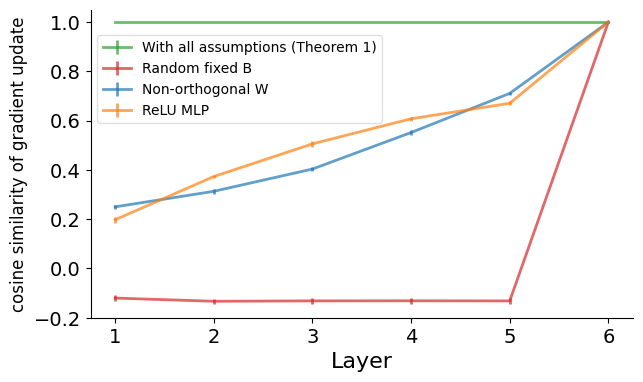

In [18]:
import matplotlib.pyplot as plt
layer_list = np.arange(1, 7)
scale = 1.97/np.sqrt(32)
plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2, 'legend.fontsize': 11, 'axes.spines.right': False, 'axes.spines.top':False, 'legend.framealpha': 0.6, 'xtick.labelsize':14, 'ytick.labelsize':14, 'figure.figsize': (7, 4)})

plt.errorbar(layer_list, mean_per_layer(total_result_dict, -1), yerr=scale*std_per_layer(total_result_dict, -1), color = 'C2', alpha=0.7, label='With all assumptions (Theorem 1)')
plt.errorbar(layer_list, mean_per_layer(total_result_dict, 0), yerr=scale*std_per_layer(total_result_dict, 0), color='C3', alpha=0.7, label='Random fixed B')
plt.errorbar(layer_list, mean_per_layer(non_orthogonal_result_dict, -1), yerr=scale*std_per_layer(non_orthogonal_result_dict, -1), alpha=0.7, label='Non-orthogonal W')
plt.errorbar(layer_list, mean_per_layer(relu_result_dict, -1), yerr=scale*std_per_layer(relu_result_dict, -1), alpha=0.7, label='ReLU MLP')
plt.legend(loc='upper left', bbox_to_anchor=(0, 0.94), fontsize=10)
plt.xlabel('Layer', fontsize=16)
plt.ylabel('cosine similarity of gradient update')
plt.ylim([-0.2, 1.05])

plt.show()